# ml_v16 : volume_ml 피처 제거 
* 나머지는 ml_v15와 일치

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, cross_validate, RandomizedSearchCV, GridSearchCV
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from lightgbm import LGBMClassifier
from scipy.stats import randint, uniform
import re, warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

DATA_PATH = r"C:\workspace\finalproject\data\ml_AmazonSephoraUlta.csv"
df_all = pd.read_csv(DATA_PATH, encoding='utf-8-sig', low_memory=False)

df_all['카테고리(중)'] = df_all['카테고리(중)'].str.lower().str.strip()

print(f"전체: {len(df_all)}개")
print(f"플랫폼별:\n{df_all['store_id'].str.split('_').str[0].value_counts().to_string()}")
print(f"\n리뷰수 있음: {df_all['리뷰수'].notna().sum()}개")
print(f"평점 있음:   {df_all['평점'].notna().sum()}개")
print(f"\ntarget_category 분포:\n{df_all['target_category'].value_counts().to_string()}")

전체: 5964개
플랫폼별:
store_id
amazon     2560
sephora    1802
ulta       1602

리뷰수 있음: 5929개
평점 있음:   5929개

target_category 분포:
target_category
skincare     3963
cleansing    1037
suncare       551
masks         413


In [67]:
# ── Y값: 정규화(평점) × 정규화(log_review_count) → 극단 30% 이진분류
# PCA 제거 근거: KMO=0.0001(부적합), Bartlett p=0.55(비유의), 음의 상관
# 복합 지수 = 질(평점) × 양(리뷰수) → 두 변수의 특성을 명시적으로 반영
df_y = df_all[
    df_all['리뷰수'].notna() &
    df_all['평점'].notna() &
    (df_all['평점'] <= 5)
].copy()

log_review             = np.log1p(df_y['리뷰수'])
df_y['y_rating_norm']  = df_y['평점'] / 5.0
df_y['y_review_norm']  = log_review / log_review.max()
df_y['y_composite']    = df_y['y_rating_norm'] * df_y['y_review_norm']

th_lo = df_y['y_composite'].quantile(0.30)
th_hi = df_y['y_composite'].quantile(0.70)
mask  = (df_y['y_composite'] <= th_lo) | (df_y['y_composite'] >= th_hi)
df_y  = df_y[mask].copy()
df_y['target'] = (df_y['y_composite'] >= th_hi).astype(int)

print(f"복합 지수 분포:")
print(f"  비인기 (하위 30%) 임계값: {th_lo:.4f}")
print(f"  인기   (상위| 30%) 임계값: {th_hi:.4f}")
print(f"\n학습 데이터: {len(df_y)}개  (긍정={df_y['target'].sum()}, 부정={len(df_y)-df_y['target'].sum()})")
print(f"플랫폼별:\n{df_y['store_id'].str.split('_').str[0].value_counts().to_string()}")

복합 지수 분포:
  비인기 (하위 30%) 임계값: 0.2639
  인기   (상위| 30%) 임계값: 0.4533

학습 데이터: 3546개  (긍정=1773, 부정=1773)
플랫폼별:
store_id
amazon     1615
ulta       1006
sephora     925


In [68]:
# ── 피처 생성
ing_cols = [c for c in df_y.columns if c.startswith('성분_')]
df_y['ingredient_text'] = df_y[ing_cols].fillna('').agg(' '.join, axis=1).str.strip()
ing_lower = df_y['ingredient_text'].str.lower()

# ── 성분 총 개수
df_y['ingredient_count'] = df_y[ing_cols].notna().sum(axis=1)
print(f"ingredient_count: mean={df_y['ingredient_count'].mean():.1f}, "
      f"median={df_y['ingredient_count'].median():.0f}, "
      f"max={df_y['ingredient_count'].max()}")

# ── 가격 연속값 + 카테고리 내 상대 순위
df_y['log_price']        = np.log1p(df_y['공급가(USD)'])
df_y['price_rank_in_cat'] = df_y.groupby('target_category')['공급가(USD)'].rank(pct=True)

# ── 가격대 bin (교호작용 피처에 필요)
price_d = pd.get_dummies(
    pd.cut(df_y['공급가(USD)'], bins=[0,30,71,9999], labels=['low','mid','high']),
    prefix='price'
).astype(int)
df_y = pd.concat([df_y, price_d], axis=1)

# 카테고리(대) 원핫
cat_d = pd.get_dummies(df_y['target_category'], prefix='cat').astype(int)
df_y = pd.concat([df_y, cat_d], axis=1)

# 카테고리(중) 원핫 (n<50 제거)
mid_counts = df_y['카테고리(중)'].value_counts()
valid_mid  = mid_counts[mid_counts >= 50].index
df_y['cat_mid'] = df_y['카테고리(중)'].where(df_y['카테고리(중)'].isin(valid_mid), other='기타')
mid_d = pd.get_dummies(df_y['cat_mid'], prefix='mid').astype(int)
df_y = pd.concat([df_y, mid_d], axis=1)

# US 트렌드 성분 20개
gt_map = {
    'gt_tocopherol':        'tocopherol',
    'gt_tocopheryl_acetate':'tocopheryl acetate',
    'gt_sodium_hyaluronate':'sodium hyaluronate',
    'gt_niacinamide':       'niacinamide',
    'gt_ceramide':          'ceramide',
    'gt_panthenol':         'panthenol',
    'gt_caprylic':          'caprylic',
    'gt_pdrn':              'polydeoxyribonucleotide',
    'gt_exosome':           'exosome',
    'gt_nad':               'nicotinamide adenine',
    'gt_bakuchiol':         'bakuchiol',
    'gt_azelaic_acid':      'azelaic acid',
    'gt_tranexamic_acid':   'tranexamic acid',
    'gt_vitamin_c':         'ascorbic',
    'gt_ectoin':            'ectoin',
    'gt_centella_asiatica': 'centella asiatica',
    'gt_peptide':           'peptide',
    'gt_squalane':          'squalane',
    'gt_caffeine':          'caffeine',
    'gt_retinol':           'retinol',
}
for feat, kw in gt_map.items():
    df_y[feat] = ing_lower.str.contains(kw, regex=True).astype(int)
gt_cols = list(gt_map.keys())
df_y['us_trend_ratio'] = df_y[gt_cols].sum(axis=1) / len(gt_cols)

# ── 클렌징 전용 피처
df_y['is_sulfate'] = ing_lower.str.contains(
    r'sodium lauryl sulfate|sodium laureth sulfate|ammonium lauryl sulfate|ammonium laureth sulfate',
    regex=True).astype(int)
df_y['is_amino_surfactant'] = ing_lower.str.contains(
    r'sodium cocoyl|potassium cocoyl|sodium lauroyl|cocoamidopropyl betaine|cocamidopropyl betaine',
    regex=True).astype(int)
df_y['is_low_ph_acid'] = ing_lower.str.contains(
    r'lactic acid|gluconolactone|lactobionic acid|mandelic acid|polyhydroxy',
    regex=True).astype(int)
df_y['surfactant_premium_score'] = (
    (df_y['is_amino_surfactant'] == 1) & (df_y['is_sulfate'] == 0)).astype(int)

# ── 클렌징 강화: 광범위 마일드 계면활성제 + 포맷 + BHA
df_y['is_mild_surfactant'] = ing_lower.str.contains(
    r'cocobetaine|coco-betaine|lauryl glucoside|coco glucoside|decyl glucoside|'
    r'caprylyl glucoside|disodium cocoamphodiacetate|sodium cocoamphoacetate|'
    r'sodium lauryl glucose carboxylate',
    regex=True).astype(int)
df_y['is_foam_cleanser'] = (
    df_y['카테고리(중)'].str.contains('foam', na=False) & (df_y['cat_cleansing'] == 1)
).astype(int)
df_y['is_gel_cleanser'] = (
    df_y['카테고리(중)'].str.contains('gel', na=False) & (df_y['cat_cleansing'] == 1)
).astype(int)
df_y['is_salicylic'] = ing_lower.str.contains('salicylic acid', regex=False).astype(int)

print(f"is_mild_surfactant 커버리지: {df_y['is_mild_surfactant'].mean()*100:.1f}%")
print(f"is_foam_cleanser   커버리지: {df_y['is_foam_cleanser'].mean()*100:.1f}%")
print(f"is_gel_cleanser    커버리지: {df_y['is_gel_cleanser'].mean()*100:.1f}%")
print(f"is_salicylic       커버리지: {df_y['is_salicylic'].mean()*100:.1f}%  "
      f"(클렌징 내: {df_y.loc[df_y['cat_cleansing']==1,'is_salicylic'].mean()*100:.1f}%)")

# ── 선케어 전용 피처
df_y['is_physical_filter'] = ing_lower.str.contains(
    r'zinc oxide|titanium dioxide', regex=True).astype(int)
df_y['has_chemical_filter'] = ing_lower.str.contains(
    r'avobenzone|octinoxate|oxybenzone|octisalate|homosalate|octocrylene|tinosorb|uvinul',
    regex=True).astype(int)
df_y['is_chemical_only'] = (
    (df_y['has_chemical_filter'] == 1) & (df_y['is_physical_filter'] == 0)).astype(int)
df_y['spf_tier'] = pd.cut(
    df_y['SPF_Index'].fillna(0), bins=[-1, 0, 30, 50, 9999], labels=[0,1,2,3]
).astype(float).fillna(0).astype(int)

# ── 교호작용: category × 신호
df_y['interact_cleansing_amino']       = df_y['cat_cleansing'] * df_y['is_amino_surfactant']
df_y['interact_cleansing_mild']        = df_y['cat_cleansing'] * df_y['is_mild_surfactant']
df_y['interact_cleansing_salicylic']   = df_y['cat_cleansing'] * df_y['is_salicylic']
df_y['interact_cleansing_sha']         = df_y['cat_cleansing'] * df_y['gt_sodium_hyaluronate']
df_y['interact_cleansing_panthenol']   = df_y['cat_cleansing'] * df_y['gt_panthenol']
df_y['interact_cleansing_niacinamide'] = df_y['cat_cleansing'] * df_y['gt_niacinamide']
df_y['interact_cleansing_trend']       = df_y['cat_cleansing'] * df_y['us_trend_ratio']
df_y['interact_cleansing_price_low']   = df_y['cat_cleansing'] * df_y['price_low']
df_y['interact_cleansing_price_mid']   = df_y['cat_cleansing'] * df_y['price_mid']
df_y['interact_skincare_trend']        = df_y['cat_skincare']  * df_y['us_trend_ratio']
df_y['interact_skincare_price_high']   = df_y['cat_skincare']  * df_y['price_high']
df_y['interact_suncare_physical']      = df_y['cat_suncare']   * df_y['is_physical_filter']
df_y['interact_suncare_spf_tier']      = df_y['cat_suncare']   * df_y['spf_tier']
df_y['interact_masks_trend']           = df_y['cat_masks']     * df_y['us_trend_ratio']
df_y['interact_masks_price_low']       = df_y['cat_masks']     * df_y['price_low']
df_y['interact_masks_price_mid']       = df_y['cat_masks']     * df_y['price_mid']
df_y['interact_suncare_price_high']    = df_y['cat_suncare']   * df_y['price_high']
df_y['interact_suncare_price_mid']     = df_y['cat_suncare']   * df_y['price_mid']

# 클렌징 내 새 성분 커버리지 확인
clean_mask = df_y['cat_cleansing'] == 1
n_clean = clean_mask.sum()
for col, label in [
    ('interact_cleansing_sha',         'sodium hyaluronate'),
    ('interact_cleansing_panthenol',   'panthenol'),
    ('interact_cleansing_niacinamide', 'niacinamide'),
]:
    n = df_y.loc[clean_mask, col].sum()
    print(f"  cleansing×{label:<22}: {int(n)}개 ({n/n_clean*100:.1f}%)")

interact_cols = [
    'interact_cleansing_amino', 'interact_cleansing_mild', 'interact_cleansing_salicylic',
    'interact_cleansing_sha', 'interact_cleansing_panthenol', 'interact_cleansing_niacinamide',
    'interact_cleansing_trend',
    'interact_cleansing_price_low', 'interact_cleansing_price_mid',
    'interact_skincare_trend', 'interact_skincare_price_high',
    'interact_suncare_physical', 'interact_suncare_spf_tier',
    'interact_masks_trend',
    'interact_masks_price_low', 'interact_masks_price_mid',
    'interact_suncare_price_high', 'interact_suncare_price_mid',
]

# ── 신규: ingredient_count × category
df_y['interact_ic_skincare']  = df_y['ingredient_count'] * df_y['cat_skincare']
df_y['interact_ic_cleansing'] = df_y['ingredient_count'] * df_y['cat_cleansing']
df_y['interact_ic_masks']     = df_y['ingredient_count'] * df_y['cat_masks']
df_y['interact_ic_suncare']   = df_y['ingredient_count'] * df_y['cat_suncare']
ic_cat_cols = [
    'interact_ic_skincare', 'interact_ic_cleansing',
    'interact_ic_masks', 'interact_ic_suncare',
]

# ── 신규: log_price × category
df_y['interact_logprice_skincare']  = df_y['log_price'] * df_y['cat_skincare']
df_y['interact_logprice_cleansing'] = df_y['log_price'] * df_y['cat_cleansing']
df_y['interact_logprice_masks']     = df_y['log_price'] * df_y['cat_masks']
df_y['interact_logprice_suncare']   = df_y['log_price'] * df_y['cat_suncare']
logprice_cat_cols = [
    'interact_logprice_skincare', 'interact_logprice_cleansing',
    'interact_logprice_masks', 'interact_logprice_suncare',
]

# ── 신규: us_trend_ratio × price bin
df_y['interact_trend_price_low']  = df_y['us_trend_ratio'] * df_y['price_low']
df_y['interact_trend_price_mid']  = df_y['us_trend_ratio'] * df_y['price_mid']
df_y['interact_trend_price_high'] = df_y['us_trend_ratio'] * df_y['price_high']
trend_price_cols = [
    'interact_trend_price_low', 'interact_trend_price_mid', 'interact_trend_price_high',
]

category_spec_cols = [
    'is_sulfate', 'is_amino_surfactant', 'is_low_ph_acid', 'surfactant_premium_score',
    'is_mild_surfactant', 'is_foam_cleanser', 'is_gel_cleanser', 'is_salicylic',
    'is_physical_filter', 'is_chemical_only', 'spf_tier',
] + interact_cols + ic_cat_cols + logprice_cat_cols + trend_price_cols

print("피처 생성 완료")

ingredient_count: mean=4.6, median=3, max=41
is_mild_surfactant 커버리지: 0.0%
is_foam_cleanser   커버리지: 9.6%
is_gel_cleanser    커버리지: 9.6%
is_salicylic       커버리지: 8.9%  (클렌징 내: 17.2%)
  cleansing×sodium hyaluronate    : 161개 (25.6%)
  cleansing×panthenol             : 61개 (9.7%)
  cleansing×niacinamide           : 69개 (11.0%)
피처 생성 완료


In [69]:
# ── 신규 성분 Position 피처 계산 (5개 성분 × 2 = 10 피처)
ing_cols_p = [c for c in df_y.columns if c.startswith('성분_')]
total_ing_count = df_y[ing_cols_p].notna().sum(axis=1).clip(lower=1)

new_position_targets = {
    'tocopheryl_acetate': 'tocopheryl acetate',
    'peptide':            'peptide',
    'panthenol':          'panthenol',
    'caffeine':           'caffeine',
    'retinol':            'retinol',
}

def find_first_idx(row, pattern):
    for i, v in enumerate(row):
        if pd.notna(v) and pattern in str(v).lower():
            return i
    return -1

# phenoxyethanol 인덱스 (1% 기준 프록시) — 한 번만 계산
pheno_idx_s = df_y[ing_cols_p].apply(
    lambda row: find_first_idx(row, 'phenoxyethanol'), axis=1
)

new_pos_cols = []
for feat, pattern in new_position_targets.items():
    idx_s = df_y[ing_cols_p].apply(
        lambda row, p=pattern: find_first_idx(row, p), axis=1
    )
    pos_col = f'{feat}_position'
    abv_col = f'{feat}_above_1pct'

    df_y[pos_col] = np.where(idx_s >= 0, 1 - idx_s / total_ing_count, -1)
    df_y[abv_col] = np.where(
        (idx_s >= 0) & (pheno_idx_s >= 0),
        (idx_s < pheno_idx_s).astype(int),
        -1
    )
    new_pos_cols += [pos_col, abv_col]

# ── citric acid position (클렌징 pH 지시 성분 — 앞쪽일수록 활성 AHA 역할)
citric_idx = df_y[ing_cols_p].apply(lambda row: find_first_idx(row, 'citric acid'), axis=1)
df_y['citric_acid_position']   = np.where(citric_idx >= 0, 1 - citric_idx / total_ing_count, -1)
df_y['interact_cleansing_citric'] = df_y['cat_cleansing'] * df_y['citric_acid_position']
new_pos_cols += ['citric_acid_position', 'interact_cleansing_citric']

print(f"신규 Position 피처 {len(new_pos_cols)}개 생성 완료")
for c in new_pos_cols:
    cov = (df_y[c] >= 0).mean() * 100
    print(f"  {c}: 커버리지 {cov:.1f}%")

신규 Position 피처 12개 생성 완료
  tocopheryl_acetate_position: 커버리지 14.2%
  tocopheryl_acetate_above_1pct: 커버리지 0.0%
  peptide_position: 커버리지 14.6%
  peptide_above_1pct: 커버리지 0.0%
  panthenol_position: 커버리지 12.0%
  panthenol_above_1pct: 커버리지 0.0%
  caffeine_position: 커버리지 7.3%
  caffeine_above_1pct: 커버리지 0.0%
  retinol_position: 커버리지 6.2%
  retinol_above_1pct: 커버리지 0.0%
  citric_acid_position: 커버리지 0.1%
  interact_cleansing_citric: 커버리지 82.3%


In [70]:
# ── 성분 Position × 카테고리 교호작용
# 의미: "특정 카테고리 제품에서 해당 성분이 앞쪽(고농도)에 있을수록 1"
# 없는 성분(position=-1)은 곱셈 후 -1 유지 → 비카테고리 제품은 0

pos_cat_pairs = [
    # (position_col,                   cat_col,        new_col)
    ('niacinamide_position',           'cat_cleansing', 'pos_clean_niacinamide'),
    ('amino_acid_surfactant_position', 'cat_cleansing', 'pos_clean_amino'),
    ('us_trend_ingredient_position',   'cat_cleansing', 'pos_clean_trend'),
    ('niacinamide_position',           'cat_skincare',  'pos_skin_niacinamide'),
    ('ceramide_position',              'cat_skincare',  'pos_skin_ceramide'),
    ('hyaluronic_acid_position',       'cat_skincare',  'pos_skin_ha'),
    ('tocopheryl_acetate_position',    'cat_skincare',  'pos_skin_tocopheryl'),
    ('retinol_position',               'cat_skincare',  'pos_skin_retinol'),
    ('zinc_oxide_position',            'cat_suncare',   'pos_sun_zinc'),
    ('us_trend_ingredient_position',   'cat_suncare',   'pos_sun_trend'),
    ('hyaluronic_acid_position',       'cat_masks',     'pos_mask_ha'),
    ('niacinamide_position',           'cat_masks',     'pos_mask_niacinamide'),
]

pos_interact_cols = []
for pos_col, cat_col, new_col in pos_cat_pairs:
    if pos_col in df_y.columns and cat_col in df_y.columns:
        df_y[new_col] = df_y[cat_col] * df_y[pos_col]
        pos_interact_cols.append(new_col)

print(f"Position × Category 교호작용 피처 {len(pos_interact_cols)}개 생성")
for c in pos_interact_cols:
    nonzero = (df_y[c] > 0).sum()
    print(f"  {c}: {nonzero}개 ({nonzero/len(df_y)*100:.1f}%)")

Position × Category 교호작용 피처 12개 생성
  pos_clean_niacinamide: 69개 (1.9%)
  pos_clean_amino: 127개 (3.6%)
  pos_clean_trend: 254개 (7.2%)
  pos_skin_niacinamide: 366개 (10.3%)
  pos_skin_ceramide: 193개 (5.4%)
  pos_skin_ha: 976개 (27.5%)
  pos_skin_tocopheryl: 335개 (9.4%)
  pos_skin_retinol: 209개 (5.9%)
  pos_sun_zinc: 14개 (0.4%)
  pos_sun_trend: 149개 (4.2%)
  pos_mask_ha: 102개 (2.9%)
  pos_mask_niacinamide: 55개 (1.6%)


In [71]:
# ── 피처 구성 + Train/Test 분리 (80/20)
from sklearn.model_selection import train_test_split

mid_feat_cols = [c for c in df_y.columns if c.startswith('mid_')]

precomp_pos_cols = [
    'niacinamide_position', 'niacinamide_above_1pct',
    'ceramide_position',    'ceramide_above_1pct',
    'hyaluronic_acid_position', 'hyaluronic_acid_above_1pct',
    'zinc_oxide_position',  'zinc_oxide_above_1pct',
    'centella_position',    'centella_above_1pct',
    'pdrn_position',        'pdrn_above_1pct',
    'amino_acid_surfactant_position',
    'top5_active_count',    'top30pct_active_count',
    'us_trend_ingredient_position', 'us_trend_ingredient_above_1pct',
]
precomp_pos_cols = [c for c in precomp_pos_cols if c in df_y.columns]
all_pos_cols = precomp_pos_cols + new_pos_cols

feat_cols = (
    ['price_low', 'price_mid', 'price_high']
    + ['log_price', 'price_rank_in_cat']     # 가격 연속값 + 카테고리 내 상대순위
    + ['SPF_Index']
    + ['ingredient_count']
    + [c for c in df_y.columns if c.startswith('cat_') and not c.startswith('cat_mid')]
    + mid_feat_cols
    + gt_cols + ['us_trend_ratio']
    + all_pos_cols
    + category_spec_cols
    + pos_interact_cols
)
feat_cols = [c for c in feat_cols if c in df_y.columns]

X_all = df_y[feat_cols].fillna(0).astype(float).values
y_all = df_y['target'].values

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, stratify=y_all, random_state=42
)

print(f"전체 피처 수: {len(feat_cols)}개")
print(f"Train: {len(y_train)}개  (긍정={y_train.sum()}, 부정={len(y_train)-y_train.sum()})")
print(f"Test:  {len(y_test)}개   (긍정={y_test.sum()}, 부정={len(y_test)-y_test.sum()})")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
auc_base = cross_validate(LGBMClassifier(random_state=42, verbose=-1),
                          X_train, y_train, cv=skf, scoring=['roc_auc'])['test_roc_auc'].mean()
print(f"\n베이스라인 Train CV AUC: {auc_base:.4f}")

전체 피처 수: 125개
Train: 2836개  (긍정=1418, 부정=1418)
Test:  710개   (긍정=355, 부정=355)

베이스라인 Train CV AUC: 0.7440


In [72]:
# ── Importance Pruning + 커버리지 5% 미만 GT 제거 (Train 기준)
low_cov = [c for c in gt_cols if df_y[feat_cols][c].mean() < 0.05]
feat_cols_pruned = [c for c in feat_cols if c not in low_cov]
print(f"커버리지 5% 미만 제거 ({len(low_cov)}개): {low_cov}")

# Train에서만 importance 계산
lgbm_full = LGBMClassifier(random_state=42, verbose=-1)
feat_idx = [feat_cols.index(c) for c in feat_cols_pruned]
lgbm_full.fit(X_train[:, feat_idx], y_train)
imp = pd.Series(lgbm_full.feature_importances_, index=feat_cols_pruned)

zero_imp = imp[imp == 0].index.tolist()
feat_cols_pruned = [c for c in feat_cols_pruned if c not in zero_imp]
print(f"Importance=0 제거 ({len(zero_imp)}개): {zero_imp}")
print(f"최종 피처 수: {len(feat_cols_pruned)}개")

# 최종 인덱스로 X 재구성
final_idx = [feat_cols.index(c) for c in feat_cols_pruned]
X_train = X_train[:, final_idx]
X_test  = X_test[:, final_idx]

auc_pruned = cross_validate(LGBMClassifier(random_state=42, verbose=-1),
                            X_train, y_train, cv=skf, scoring=['roc_auc'])['test_roc_auc'].mean()
print(f"\n정제 후 Train CV AUC: {auc_pruned:.4f}")

print("\nTop 20 피처 중요도:")
print(imp[feat_cols_pruned].sort_values(ascending=False).head(20).to_string())

feat_cols = feat_cols_pruned

커버리지 5% 미만 제거 (11개): ['gt_tocopherol', 'gt_caprylic', 'gt_pdrn', 'gt_exosome', 'gt_nad', 'gt_bakuchiol', 'gt_azelaic_acid', 'gt_tranexamic_acid', 'gt_ectoin', 'gt_centella_asiatica', 'gt_squalane']
Importance=0 제거 (27개): ['cat_skincare', 'zinc_oxide_above_1pct', 'centella_above_1pct', 'pdrn_position', 'pdrn_above_1pct', 'tocopheryl_acetate_above_1pct', 'peptide_above_1pct', 'panthenol_above_1pct', 'caffeine_above_1pct', 'retinol_above_1pct', 'citric_acid_position', 'is_sulfate', 'is_amino_surfactant', 'is_low_ph_acid', 'surfactant_premium_score', 'is_mild_surfactant', 'is_gel_cleanser', 'spf_tier', 'interact_cleansing_amino', 'interact_cleansing_mild', 'interact_cleansing_salicylic', 'interact_cleansing_panthenol', 'interact_cleansing_niacinamide', 'interact_cleansing_price_mid', 'interact_skincare_price_high', 'interact_suncare_price_high', 'pos_sun_zinc']
최종 피처 수: 87개

정제 후 Train CV AUC: 0.7461

Top 20 피처 중요도:
log_price                       417
price_rank_in_cat               244
in

In [73]:
# ── Optuna 하이퍼파라미터 튜닝 (n_trials=200, TPE 베이지안 탐색)
import optuna
from sklearn.model_selection import cross_val_score
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 800),
        'max_depth':         trial.suggest_int('max_depth', 3, 12),
        'num_leaves':        trial.suggest_int('num_leaves', 15, 150),
        'learning_rate':     trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 60),
        'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-8, 1.0, log=True),
        'random_state': 42,
        'verbose': -1,
    }
    return cross_val_score(
        LGBMClassifier(**params), X_train, y_train,
        cv=skf, scoring='roc_auc', n_jobs=-1
    ).mean()

study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42)
)
study.optimize(objective, n_trials=200, show_progress_bar=True)

print(f"최적 Train CV AUC: {study.best_value:.4f}")
print(f"최적 파라미터: {study.best_params}")

  0%|          | 0/200 [00:00<?, ?it/s]

최적 Train CV AUC: 0.7531
최적 파라미터: {'n_estimators': 367, 'max_depth': 12, 'num_leaves': 95, 'learning_rate': 0.01466067810462404, 'min_child_samples': 24, 'subsample': 0.5115773777089486, 'colsample_bytree': 0.5217362581121124, 'reg_alpha': 0.0031134605389229798, 'reg_lambda': 5.000850759418977e-08}


In [74]:
# ── Optuna 최적 파라미터로 최종 모델 구성 (downstream 셀 호환용 gs 래퍼)
best_params = {**study.best_params, 'random_state': 42, 'verbose': -1}

class _OptunaResult:
    def __init__(self, params, score):
        self.best_estimator_ = LGBMClassifier(**params)
        self.best_score_ = score

gs = _OptunaResult(best_params, study.best_value)
print(f"Optuna 최적 Train CV AUC : {gs.best_score_:.4f}")
print(f"파라미터 : {best_params}")

Optuna 최적 Train CV AUC : 0.7531
파라미터 : {'n_estimators': 367, 'max_depth': 12, 'num_leaves': 95, 'learning_rate': 0.01466067810462404, 'min_child_samples': 24, 'subsample': 0.5115773777089486, 'colsample_bytree': 0.5217362581121124, 'reg_alpha': 0.0031134605389229798, 'reg_lambda': 5.000850759418977e-08, 'random_state': 42, 'verbose': -1}


Train CV AUC : 0.7531
Test AUC     : 0.7548
과적합 갭    : -0.0018

[Train OOF] Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.67      0.68      1418
           1       0.68      0.71      0.69      1418

    accuracy                           0.69      2836
   macro avg       0.69      0.69      0.69      2836
weighted avg       0.69      0.69      0.69      2836

[Test] Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.62      0.65       355
           1       0.66      0.73      0.69       355

    accuracy                           0.67       710
   macro avg       0.68      0.67      0.67       710
weighted avg       0.68      0.67      0.67       710



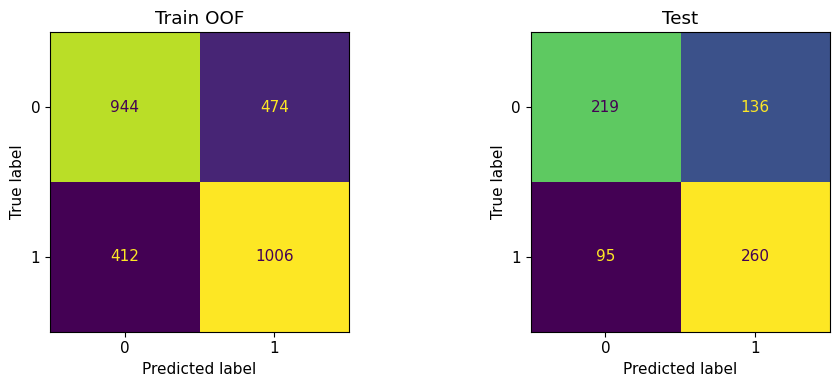

In [75]:
# ── 최종 Test set 평가 (1회만 실행)
from sklearn.model_selection import cross_val_predict

final_model = gs.best_estimator_
final_model.fit(X_train, y_train)

test_auc  = roc_auc_score(y_test, final_model.predict_proba(X_test)[:, 1])
train_auc = gs.best_score_

print(f"Train CV AUC : {train_auc:.4f}")
print(f"Test AUC     : {test_auc:.4f}")
print(f"과적합 갭    : {train_auc - test_auc:+.4f}")

# OOF Confusion Matrix (Train 기준)
y_oof = cross_val_predict(final_model, X_train, y_train, cv=skf, method='predict')
print(f"\n[Train OOF] Classification Report:")
print(classification_report(y_train, y_oof))

# Test Confusion Matrix
print(f"[Test] Classification Report:")
print(classification_report(y_test, final_model.predict(X_test)))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ConfusionMatrixDisplay.from_predictions(y_train, y_oof, ax=axes[0], colorbar=False)
axes[0].set_title("Train OOF")
ConfusionMatrixDisplay.from_predictions(y_test, final_model.predict(X_test), ax=axes[1], colorbar=False)
axes[1].set_title("Test")
plt.tight_layout()
plt.show()

=== 카테고리별 Test 성능 ===

카테고리                 n      긍정비율      AUC       F1  신뢰도
-----------------------------------------------------------------
skincare           491     48.3%   0.7738   0.6843  ✅ 신뢰
cleansing          114     60.5%   0.6649   0.7123  ✅ 신뢰
masks               46     39.1%   0.7917   0.6486  △ 참고
suncare             59     52.5%   0.6924   0.7273  ✅ 신뢰
-----------------------------------------------------------------
전체                 710     50.0%   0.7548   0.6924


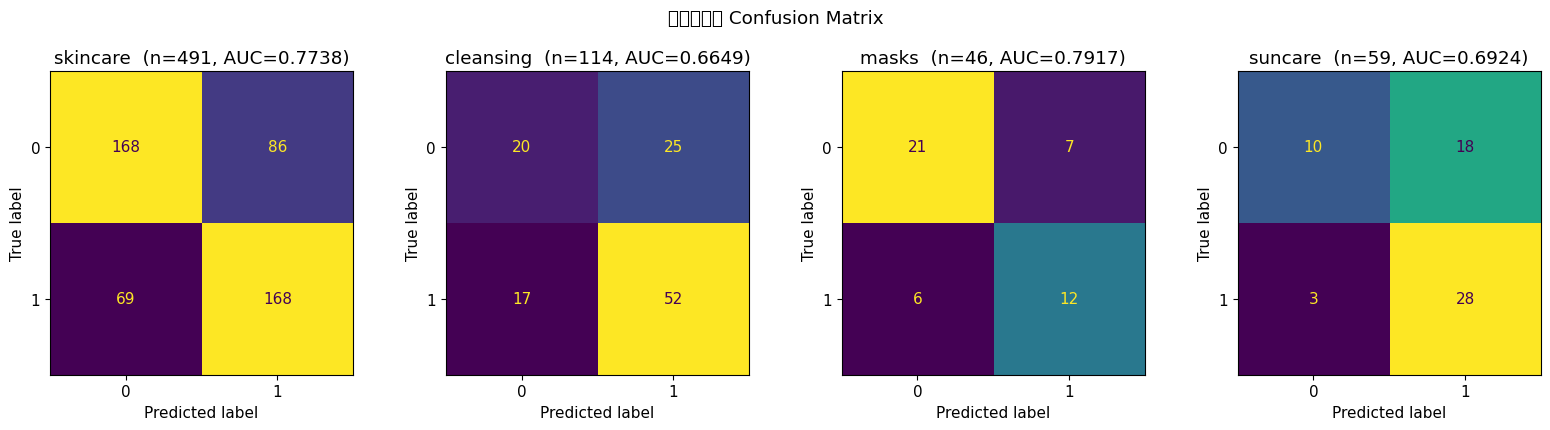

In [76]:
# ── 카테고리별 예측 성능 분석
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split as _tts

_indices = np.arange(len(df_y))
_, _test_idx = _tts(_indices, test_size=0.2, stratify=y_all, random_state=42)

test_cats  = df_y['target_category'].iloc[_test_idx].reset_index(drop=True)
test_proba = final_model.predict_proba(X_test)[:, 1]
test_pred  = final_model.predict(X_test)

print("=== 카테고리별 Test 성능 ===\n")
print(f"{'카테고리':<16} {'n':>5}  {'긍정비율':>8}  {'AUC':>7}  {'F1':>7}  신뢰도")
print("-" * 65)

for cat in ['skincare', 'cleansing', 'masks', 'suncare']:
    mask     = (test_cats == cat).values
    n        = mask.sum()
    pos_rate = y_test[mask].mean() if n > 0 else 0
    if n == 0 or len(np.unique(y_test[mask])) < 2 or n < 15:
        print(f"{cat:<16} {n:>5}  {pos_rate:>8.1%}  {'N/A':>7}  {'N/A':>7}  ⚠ 샘플 부족")
        continue
    cat_auc = roc_auc_score(y_test[mask], test_proba[mask])
    cat_f1  = f1_score(y_test[mask], test_pred[mask])
    trust   = "✅ 신뢰" if n >= 50 else "△ 참고"
    print(f"{cat:<16} {n:>5}  {pos_rate:>8.1%}  {cat_auc:>7.4f}  {cat_f1:>7.4f}  {trust}")

print("-" * 65)
print(f"{'전체':<16} {len(y_test):>5}  {y_test.mean():>8.1%}  "
      f"{roc_auc_score(y_test, test_proba):>7.4f}  {f1_score(y_test, test_pred):>7.4f}")

cats_to_plot = [c for c in ['skincare', 'cleansing', 'masks', 'suncare']
                if (test_cats == c).sum() >= 15 and len(np.unique(y_test[(test_cats == c).values])) >= 2]
fig, axes = plt.subplots(1, len(cats_to_plot), figsize=(4 * len(cats_to_plot), 4))
if len(cats_to_plot) == 1: axes = [axes]
for ax, cat in zip(axes, cats_to_plot):
    mask = (test_cats == cat).values
    auc  = roc_auc_score(y_test[mask], test_proba[mask])
    ConfusionMatrixDisplay.from_predictions(y_test[mask], test_pred[mask], ax=ax, colorbar=False)
    ax.set_title(f"{cat}  (n={mask.sum()}, AUC={auc:.4f})")
plt.suptitle("카테고리별 Confusion Matrix", y=1.02)
plt.tight_layout()
plt.show()

In [77]:
# ── 전체 카테고리 Threshold 최적화 (Train OOF 기반)
from sklearn.model_selection import cross_val_predict, train_test_split as _tts
from sklearn.metrics import precision_score, recall_score

oof_proba = cross_val_predict(final_model, X_train, y_train, cv=skf, method='predict_proba')[:, 1]

_indices_all = np.arange(len(df_y))
_train_idx2, _ = _tts(_indices_all, test_size=0.2, stratify=y_all, random_state=42)
train_cats = df_y['target_category'].iloc[_train_idx2].reset_index(drop=True)

CATEGORY_THRESHOLDS = {}

print("=== 카테고리별 Threshold 최적화 (Train OOF 기반) ===\n")

for cat in ['skincare', 'cleansing', 'masks', 'suncare']:
    oof_mask  = (train_cats == cat).values
    test_mask = (test_cats  == cat).values

    oof_p    = oof_proba[oof_mask]
    y_oof_c  = y_train[oof_mask]
    y_test_c = y_test[test_mask]
    test_p   = test_proba[test_mask]

    n_train  = oof_mask.sum()
    pos_rate = y_oof_c.mean()

    # OOF 기준 0.50 F1
    f1_at_50 = f1_score(y_oof_c, (oof_p >= 0.50).astype(int))

    # 탐색 하한: 긍정비율 < 45% → 0.30까지, 그 외 → 0.35까지
    # (긍정비율 50%+ 카테고리에서 0.25는 너무 공격적 → OOF 과적합)
    th_min = 0.30 if pos_rate < 0.45 else 0.35

    best_th, best_f1 = 0.50, f1_at_50
    for th in np.arange(th_min, 0.70, 0.05):
        pred = (oof_p >= th).astype(int)
        if len(np.unique(pred)) < 2:
            continue
        f1 = f1_score(y_oof_c, pred)
        if f1 > best_f1:
            best_f1, best_th = f1, th

    CATEGORY_THRESHOLDS[cat] = round(float(best_th), 2)

    # Test 성능 비교
    f1_default = f1_score(y_test_c, (test_p >= 0.50).astype(int))
    f1_tuned   = f1_score(y_test_c, (test_p >= best_th).astype(int))
    auc_cat    = roc_auc_score(y_test_c, test_p) if len(np.unique(y_test_c)) >= 2 else float('nan')

    print(f"[{cat}]  Train n={n_train}  긍정비율={pos_rate:.1%}  (탐색범위: {th_min:.2f}~0.65)")
    print(f"  최적 threshold (OOF): {best_th:.2f}  (OOF F1@0.50={f1_at_50:.4f} → best={best_f1:.4f})")
    print(f"  Test AUC           : {auc_cat:.4f}")
    print(f"  Test F1 (th=0.50)  : {f1_default:.4f}")
    print(f"  Test F1 (th={best_th:.2f})  : {f1_tuned:.4f}  ({f1_tuned - f1_default:+.4f})")
    print()

print(f"CATEGORY_THRESHOLDS = {CATEGORY_THRESHOLDS}")


=== 카테고리별 Threshold 최적화 (Train OOF 기반) ===

[skincare]  Train n=1880  긍정비율=47.1%  (탐색범위: 0.35~0.65)
  최적 threshold (OOF): 0.35  (OOF F1@0.50=0.6720 → best=0.6969)
  Test AUC           : 0.7738
  Test F1 (th=0.50)  : 0.6843
  Test F1 (th=0.35)  : 0.7458  (+0.0614)

[cleansing]  Train n=515  긍정비율=63.1%  (탐색범위: 0.35~0.65)
  최적 threshold (OOF): 0.35  (OOF F1@0.50=0.7591 → best=0.7830)
  Test AUC           : 0.6649
  Test F1 (th=0.50)  : 0.7123
  Test F1 (th=0.35)  : 0.7590  (+0.0467)

[masks]  Train n=197  긍정비율=34.5%  (탐색범위: 0.30~0.65)
  최적 threshold (OOF): 0.30  (OOF F1@0.50=0.6271 → best=0.6832)
  Test AUC           : 0.7917
  Test F1 (th=0.50)  : 0.6486
  Test F1 (th=0.30)  : 0.6957  (+0.0470)

[suncare]  Train n=244  긍정비율=57.0%  (탐색범위: 0.35~0.65)
  최적 threshold (OOF): 0.35  (OOF F1@0.50=0.6962 → best=0.7416)
  Test AUC           : 0.6924
  Test F1 (th=0.50)  : 0.7273
  Test F1 (th=0.35)  : 0.7126  (-0.0146)

CATEGORY_THRESHOLDS = {'skincare': 0.35, 'cleansing': 0.35, 'masks': 0.3, 'sun

In [ ]:
# ── 최종 모델 저장
import os, joblib

final_model = gs.best_estimator_
final_model.fit(X_train, y_train)

test_auc = roc_auc_score(y_test, final_model.predict_proba(X_test)[:, 1])
print(f"=== 최종 모델 성능 ===")
print(f"ml_v16 (베이스라인, volume_ml 제거)                    : 0.7300")
print(f"ml_v17 (log_price + 교호작용 확대)                     : 0.7462")
print(f"ml_v18 (cleansing 강화: mild surfactant + 포맷)        : {test_auc:.4f}")

print(f"\nCATEGORY_THRESHOLDS: {CATEGORY_THRESHOLDS}")

# predictor의 price_rank_in_cat 계산을 위해 학습 데이터 가격 분포 저장
price_arrays = {
    cat: df_y.loc[df_y['target_category'] == cat, '공급가(USD)'].dropna().tolist()
    for cat in ['skincare', 'cleansing', 'masks', 'suncare']
}

save_candidates = [
    r"C:\workspace\finalproject\data\model_output",
    r"C:\workspace\finalproject\finalteam4\ml",
    os.path.expanduser("~"),
]
save_dir = next((d for d in save_candidates if os.path.isdir(d) or not os.path.exists(d)), ".")
os.makedirs(save_dir, exist_ok=True)

model_data = {
    'model':                final_model,
    'feat_cols':            feat_cols,
    'gt_map':               gt_map,
    'new_position_targets': new_position_targets,
    'category_spec_cols':   category_spec_cols,
    'category_thresholds':  CATEGORY_THRESHOLDS,
    'price_arrays':         price_arrays,          # predictor용 가격 분포
    'y_type':               'composite_rating_x_review',
}

save_path = os.path.join(save_dir, 'lgbm_v18.pkl')
try:
    joblib.dump(model_data, save_path)
    print(f"\n모델 저장 완료: {save_path}")
except OSError:
    alt_path = os.path.join(os.path.expanduser("~"), 'lgbm_v18.pkl')
    joblib.dump(model_data, alt_path)
    print(f"대체 경로 저장: {alt_path}")
    save_path = alt_path

print(f"저장 피처 수: {len(feat_cols)}개")
for cat, arr in price_arrays.items():
    print(f"  price_arrays[{cat}]: {len(arr)}개")
